## Import Required Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## Set Dataset Paths

In [3]:
train_dir = "dataset/Training"
test_dir = "dataset/Testing"

print("Training Path:", train_dir)
print("Testing Path:", test_dir)

Training Path: dataset/Training
Testing Path: dataset/Testing


## Check Dataset Classes

In [4]:
print("Training Classes:")
print(os.listdir(train_dir))

print("\nTesting Classes:")
print(os.listdir(test_dir))

Training Classes:
['.ipynb_checkpoints', 'glioma', 'meningioma', 'notumor', 'pituitary']

Testing Classes:
['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\MY PC\NLP-ITR-2026\Brain_Tumor_Detection_CNN
['.ipynb_checkpoints', '01_Data_Preprocessing.ipynb', '02_Model_Training.ipynb', 'app.py', 'dataset', 'model', 'requirements.txt', 'tumor_info.py']


## Count Images in Each Class

In [6]:
print("Training Images")

for folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, folder)
    total_images = len(os.listdir(folder_path))
    print(f"{folder}: {total_images}")

print("\nTesting Images")

for folder in os.listdir(test_dir):
    folder_path = os.path.join(test_dir, folder)
    total_images = len(os.listdir(folder_path))
    print(f"{folder}: {total_images}")

Training Images
.ipynb_checkpoints: 0
glioma: 1400
meningioma: 1400
notumor: 1400
pituitary: 1400

Testing Images
glioma: 401
meningioma: 400
notumor: 400
pituitary: 400


## Display Sample Images

In [7]:
for class_name in os.listdir(train_dir):
    folder = os.path.join(train_dir, class_name)
    print(class_name, len(os.listdir(folder)))

.ipynb_checkpoints 0
glioma 1400
meningioma 1400
notumor 1400
pituitary 1400


In [8]:
# Check All Training Folders

for class_name in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, class_name)
    
    print(class_name, "=>", len(os.listdir(folder_path)))

.ipynb_checkpoints => 0
glioma => 1400
meningioma => 1400
notumor => 1400
pituitary => 1400


## Display Sample Images

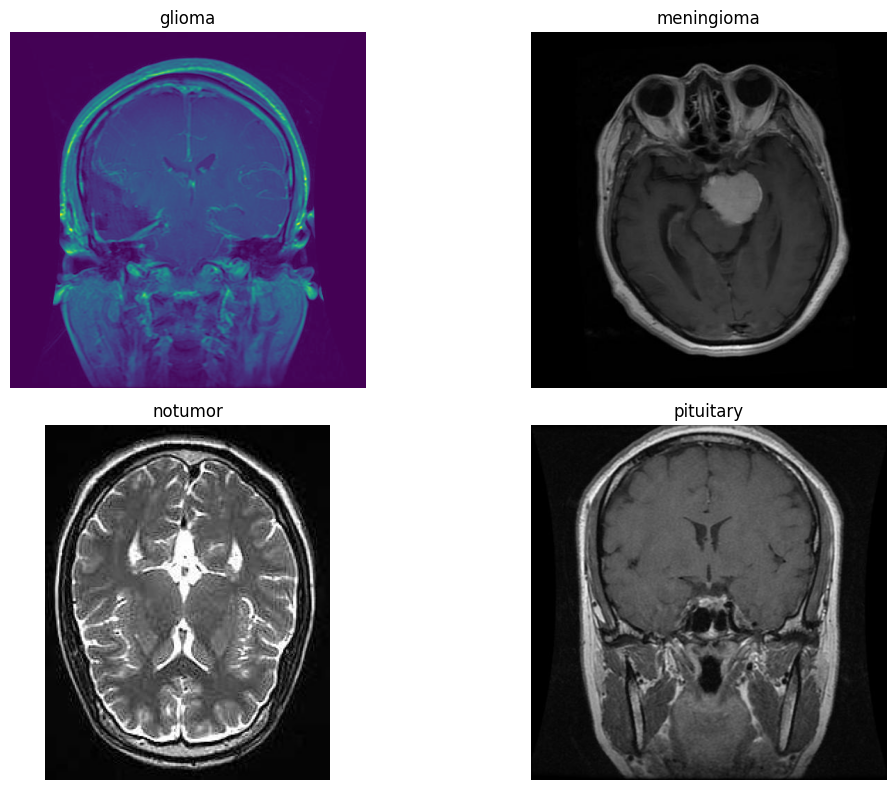

In [9]:
classes = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):

    image_path = os.path.join(
        train_dir,
        class_name,
        os.listdir(os.path.join(train_dir, class_name))[0]
    )

    image = plt.imread(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Set Image Parameters

In [10]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

print("Image Size:", IMAGE_SIZE)
print("Batch Size:", BATCH_SIZE)

Image Size: (224, 224)
Batch Size: 32


## Create Training Data Generator

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Create Testing Data Generator

In [12]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Load Training and Testing Data

In [13]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 5600 images belonging to 5 classes.
Found 1601 images belonging to 4 classes.


## Display Class Information

In [14]:
print("Class Indices:")
print(train_generator.class_indices)

print("\nNumber of Classes:", len(train_generator.class_indices))

Class Indices:
{'.ipynb_checkpoints': 0, 'glioma': 1, 'meningioma': 2, 'notumor': 3, 'pituitary': 4}

Number of Classes: 5


# Check Batch Shape

In [15]:
images, labels = next(train_generator)

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32, 5)


## Display Batch Images

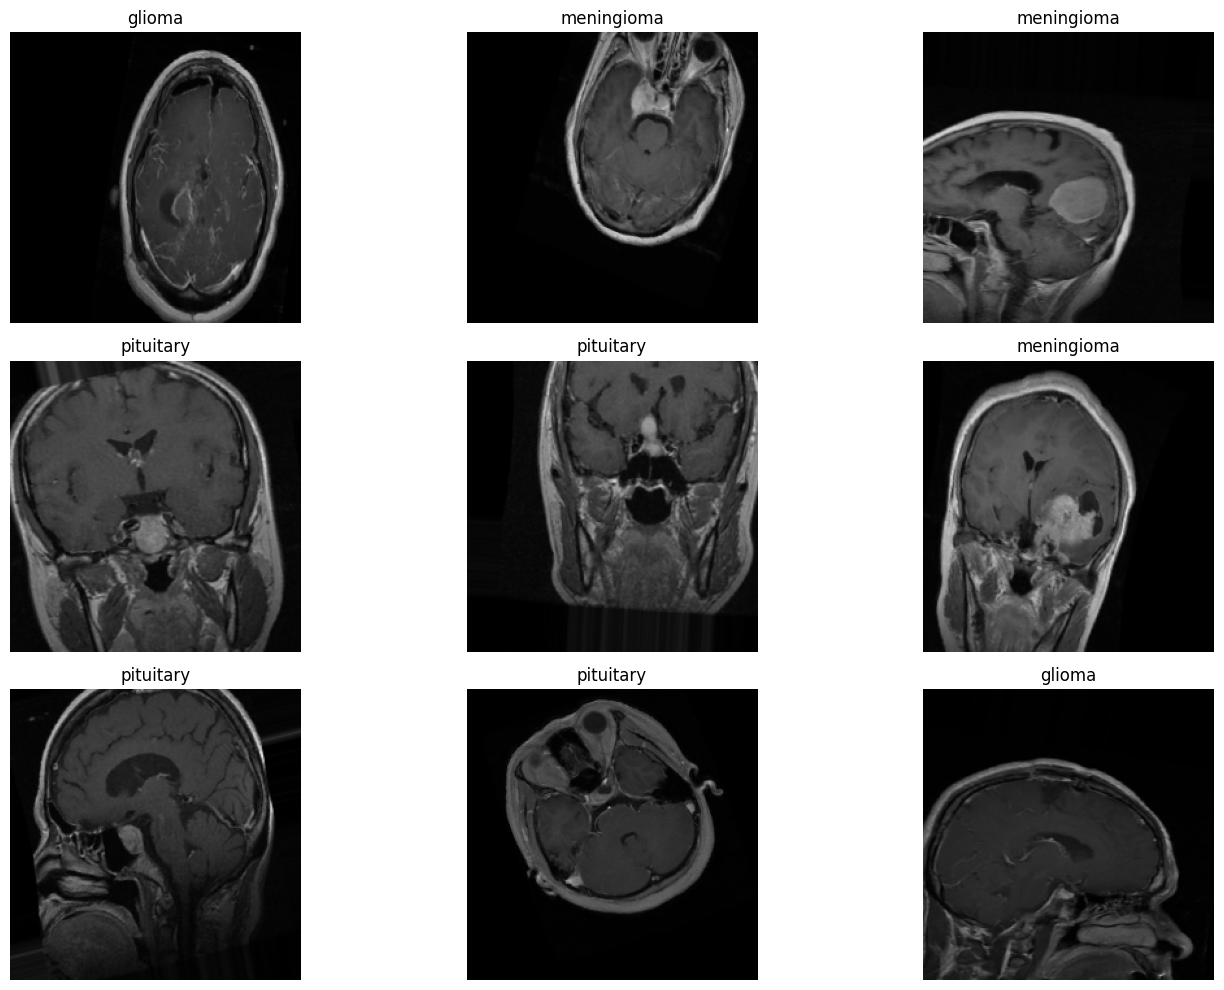

In [16]:
class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(15, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Display Class Indices

In [17]:
print("Class Indices")

for class_name, index in train_generator.class_indices.items():
    print(f"{index} : {class_name}")

Class Indices
0 : .ipynb_checkpoints
1 : glioma
2 : meningioma
3 : notumor
4 : pituitary


# Dataset Summary

In [18]:
print("Training Samples :", train_generator.samples)
print("Testing Samples :", test_generator.samples)

print("Training Steps :", len(train_generator))
print("Testing Steps :", len(test_generator))

Training Samples : 5600
Testing Samples : 1601
Training Steps : 175
Testing Steps : 51


# Preprocessing Completed

In [19]:
print("=" * 50)
print("Brain Tumor Dataset Preprocessing Completed Successfully")
print("=" * 50)

Brain Tumor Dataset Preprocessing Completed Successfully
